# Module 1 - Classification with Imbalanced Learning

**Task:** Classify the Severity Impairment Index (`sii`) using a Decision Tree, applying imbalanced learning techniques:
- **Undersampling 1:** Tomek Links
- **Undersampling 2:** Edited Nearest Neighbors (ENN)
- **Undersampling 3:** Random Undersampling
- **Oversampling:** ADASYN

**Metrics:** Accuracy, Precision, Recall, F1-score, ROC Curve (OvR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, make_scorer
)
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours, RandomUnderSampler
from imblearn.over_sampling import ADASYN
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col='id')
print(f"Shape: {df.shape}")
df.head()

Shape: (8203, 19)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,
0,5.0,0,51.0,116.840000,23.042474,84.333333,2.0,16.8792,1492.00,41.5862,13.817700,3.06143,1.0,3.0,2.0,82.555556,2.123081,3,2.500000
1,9.0,0,60.5,121.920000,20.865232,70.000000,2.0,14.0371,1498.65,42.0291,12.825400,1.21172,1.0,0.0,0.0,90.666667,0.828527,4,2.175000
2,10.0,1,71.0,143.510000,34.291555,94.000000,3.0,17.9665,1863.98,61.0662,14.092500,3.69863,2.0,2.0,0.0,82.333333,5.546522,5,2.088333
3,9.0,0,71.0,142.240000,37.013107,97.000000,3.0,18.2943,1923.44,62.7757,14.074000,4.22033,2.0,0.0,1.0,79.000000,6.967458,4,2.230500
4,18.0,1,65.0,137.862733,34.926584,89.000000,3.0,17.9665,1863.98,61.0662,15.141363,3.69863,2.0,1.0,0.0,83.388889,5.649235,5,1.885000


In [3]:
X = df.drop(columns=["sii"])
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
print("Original class distribution:")
print(y.value_counts().sort_index())

Original class distribution:
sii
0    5666
1    1538
2     917
3      82
Name: count, dtype: int64


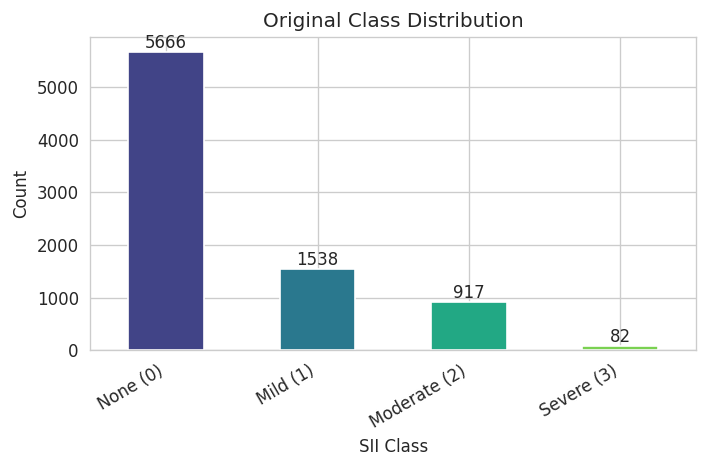

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar", color=sns.color_palette("viridis", 4), ax=ax)
ax.set_xlabel("SII Class")
ax.set_ylabel("Count")
ax.set_title("Original Class Distribution")
ax.set_xticklabels(class_names, rotation=30, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
               ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Train/Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Train: {X_train_scaled.shape[0]} samples | Test: {X_test_scaled.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")

Train: 6562 samples | Test: 1641 samples

Train class distribution:
sii
0    4532
1    1230
2     734
3      66
Name: count, dtype: int64


## 3. Resampling Techniques

We apply four strategies to the **training set only**:
1. **Tomek Links** — undersampling: removes Tomek pairs (borderline majority samples)
2. **Edited Nearest Neighbours (ENN)** — undersampling: removes majority samples misclassified by their neighbors
3. **Random Undersampling** — undersampling: randomly removes majority-class samples to balance the distribution
4. **ADASYN** — oversampling: generates adaptive synthetic minority samples

In [6]:
# Undersampling 1: Tomek Links
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_train_scaled, y_train)
print(f"After Tomek Links:          {Counter(y_tomek)}")

# Undersampling 2: Edited Nearest Neighbours (only remove majority-class samples)
enn = EditedNearestNeighbours(n_neighbors=3, kind_sel="mode")
X_enn, y_enn = enn.fit_resample(X_train_scaled, y_train)
print(f"After ENN:                  {Counter(y_enn)}")

# Undersampling 3: Random Undersampling
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"After Random Undersampling: {Counter(y_rus)}")

After Tomek Links:          Counter({0: 4125, 1: 909, 2: 561, 3: 66})
After ENN:                  Counter({0: 4018, 1: 142, 3: 66, 2: 59})
After Random Undersampling: Counter({0: 66, 1: 66, 2: 66, 3: 66})


In [7]:
# Oversampling: ADASYN
adasyn = ADASYN(random_state=RANDOM_STATE, n_neighbors=5)
X_over, y_over = adasyn.fit_resample(X_train_scaled, y_train)
print(f"After ADASYN: {Counter(y_over)}")

After ADASYN: Counter({0: 4532, 3: 4528, 2: 4527, 1: 4520})


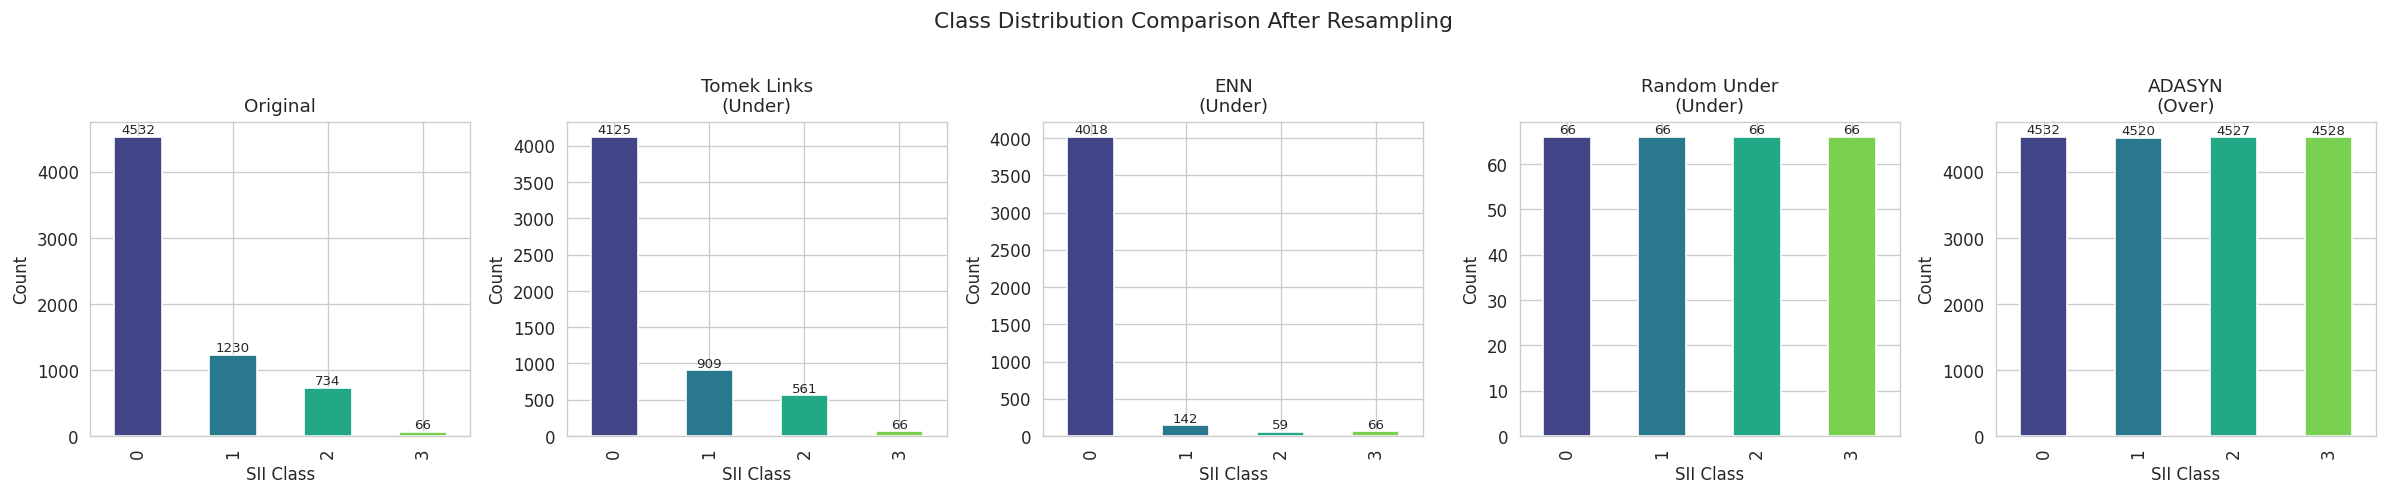

In [8]:
# Compare class distributions
datasets = {
    "Original": y_train,
    "Tomek Links\n(Under)": y_tomek,
    "ENN\n(Under)": y_enn,
    "Random Under\n(Under)": y_rus,
    "ADASYN\n(Over)": y_over,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
colors = sns.color_palette("viridis", 4)

for ax, (name, labels) in zip(axes, datasets.items()):
    counts = pd.Series(labels).value_counts().sort_index()
    counts.plot(kind="bar", color=colors, ax=ax)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("SII Class")
    ax.set_ylabel("Count")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                   ha="center", va="bottom", fontsize=8)

plt.suptitle("Class Distribution Comparison After Resampling", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning — Decision Tree with GridSearchCV + StratifiedKFold

For each resampled dataset (and the baseline), we tune the Decision Tree using **5-fold stratified cross-validation** over a grid of typical hyperparameters, optimizing for **macro F1** (better suited for imbalanced problems than accuracy).

In [9]:
resampled_sets = {
    "Baseline (No Resampling)": (X_train_scaled, y_train),
    "Tomek Links (Under)": (X_tomek, y_tomek),
    "ENN (Under)": (X_enn, y_enn),
    "Random Under (Under)": (X_rus, y_rus),
    "ADASYN (Over)": (X_over, y_over),
}

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "criterion": ["gini", "entropy", "log_loss"],
    "class_weight": ["balanced", None],
    "max_features": ["sqrt", "log2", None],
    "splitter": ["best", "random"],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(f1_score, average="macro", zero_division=0)

In [10]:
results = {}

for resample_name, (X_tr, y_tr) in resampled_sets.items():
    print(f"\n{'='*70}")
    print(f"Tuning Decision Tree | {resample_name}")
    print(f"{'='*70}")

    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_grid,
        cv=skf,
        scoring=scorer,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_tr, y_tr)

    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)

    results[resample_name] = {
        "model": best,
        "y_pred": y_pred,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    print(f"Best params: {grid.best_params_}")
    print(f"Best CV F1 (macro): {grid.best_score_:.4f}")
    print(f"\nTest set results:")
    print(f"Accuracy: {results[resample_name]['accuracy']:.4f}")
    print(f"Precision (macro): {results[resample_name]['precision_macro']:.4f}")
    print(f"Recall (macro): {results[resample_name]['recall_macro']:.4f}")
    print(f"F1 (macro): {results[resample_name]['f1_macro']:.4f}")
    print(f"F1 (weighted): {results[resample_name]['f1_weighted']:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names, zero_division=0)}")


Tuning Decision Tree | Baseline (No Resampling)
Best params: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}
Best CV F1 (macro): 0.2963

Test set results:
Accuracy: 0.5899
Precision (macro): 0.3456
Recall (macro): 0.2767
F1 (macro): 0.2852
F1 (weighted): 0.5633

              precision    recall  f1-score   support

    None (0)       0.71      0.79      0.75      1134
    Mild (1)       0.20      0.16      0.18       308
Moderate (2)       0.14      0.09      0.11       183
  Severe (3)       0.33      0.06      0.11        16

    accuracy                           0.59      1641
   macro avg       0.35      0.28      0.29      1641
weighted avg       0.54      0.59      0.56      1641


Tuning Decision Tree | Tomek Links (Under)
Best params: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'min_samples_

## 5. Confusion Matrices

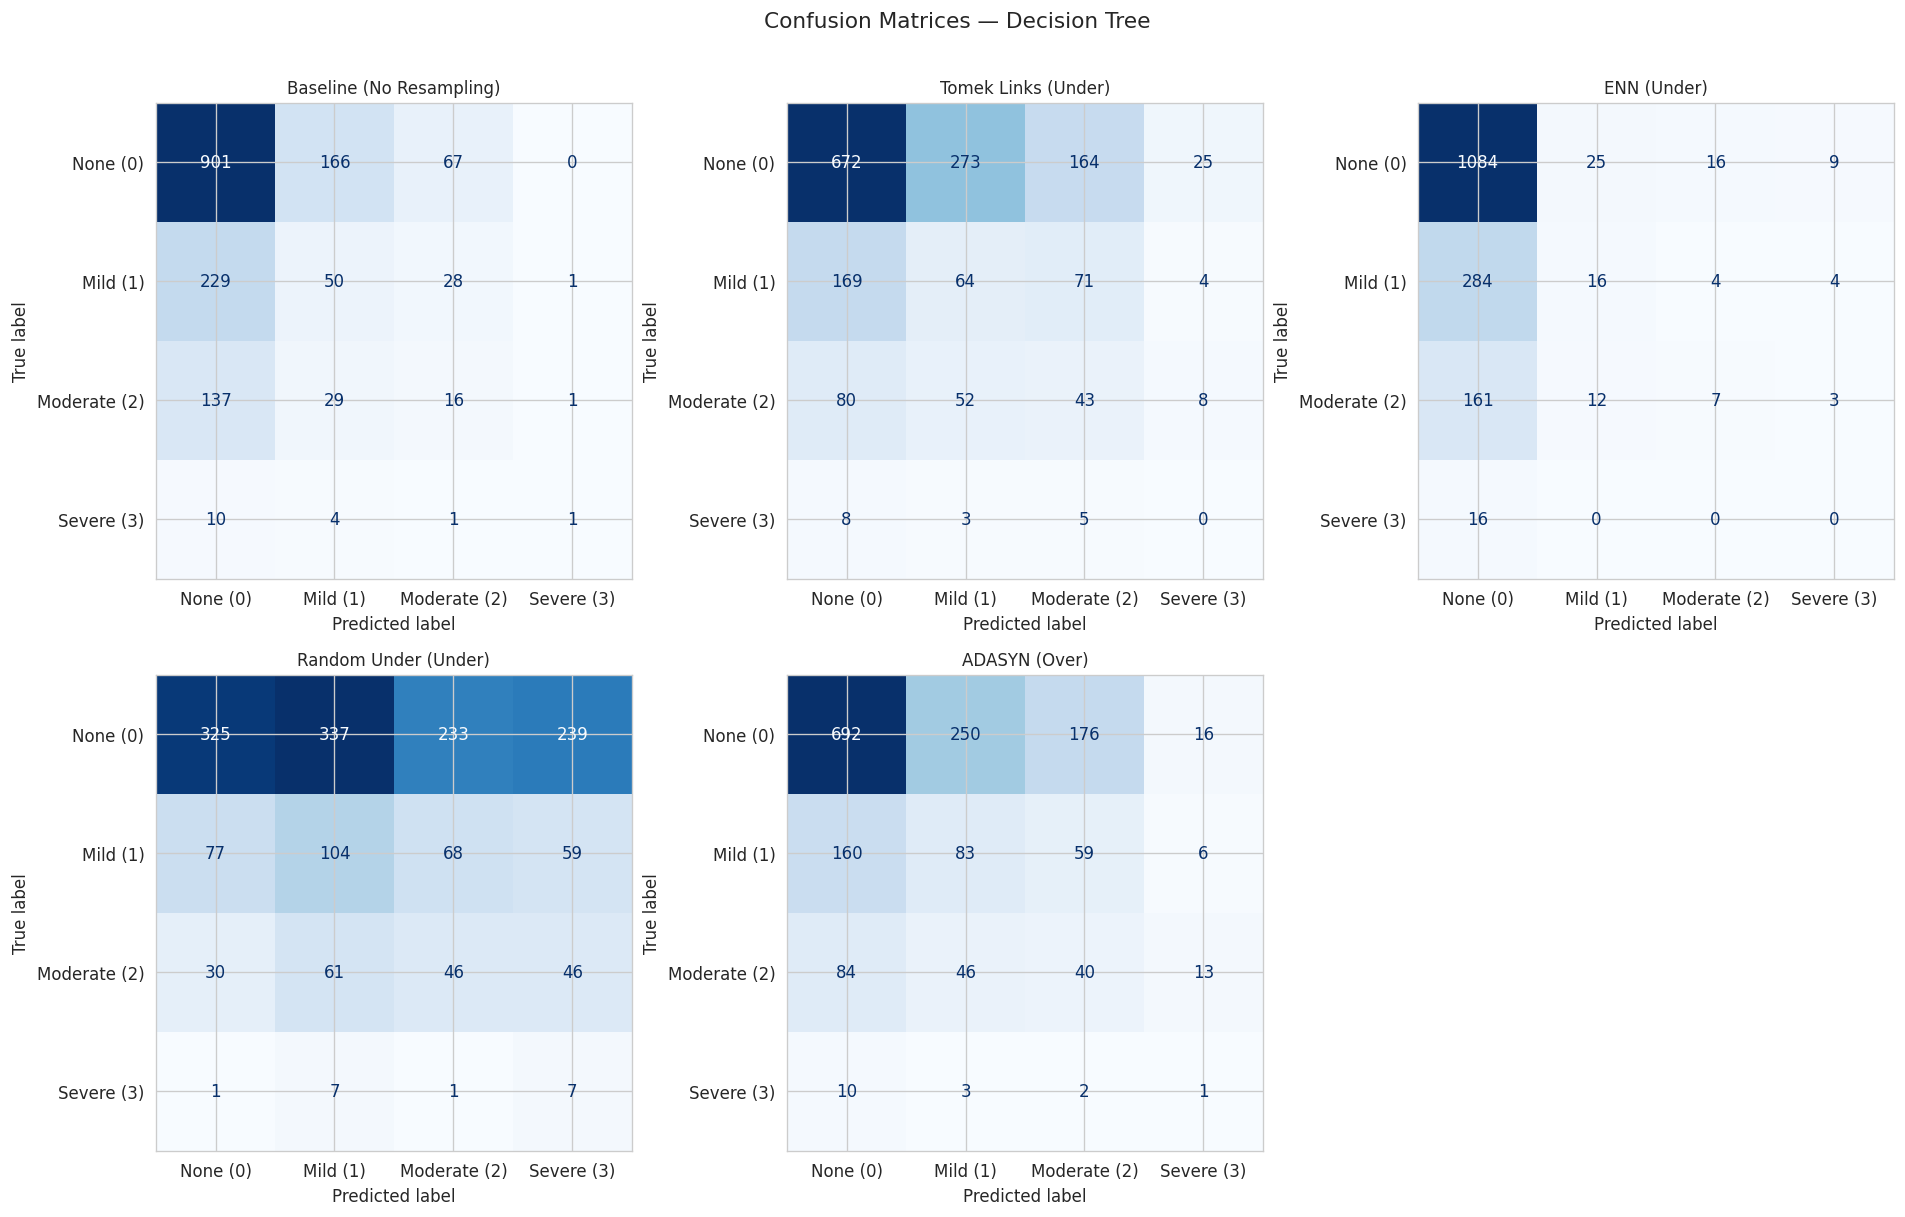

In [11]:
n_methods = len(results)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (key, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(key, fontsize=10)

# Hide unused subplot
axes[1, 2].set_visible(False)

plt.suptitle("Confusion Matrices — Decision Tree", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. ROC Curves (One-vs-Rest)

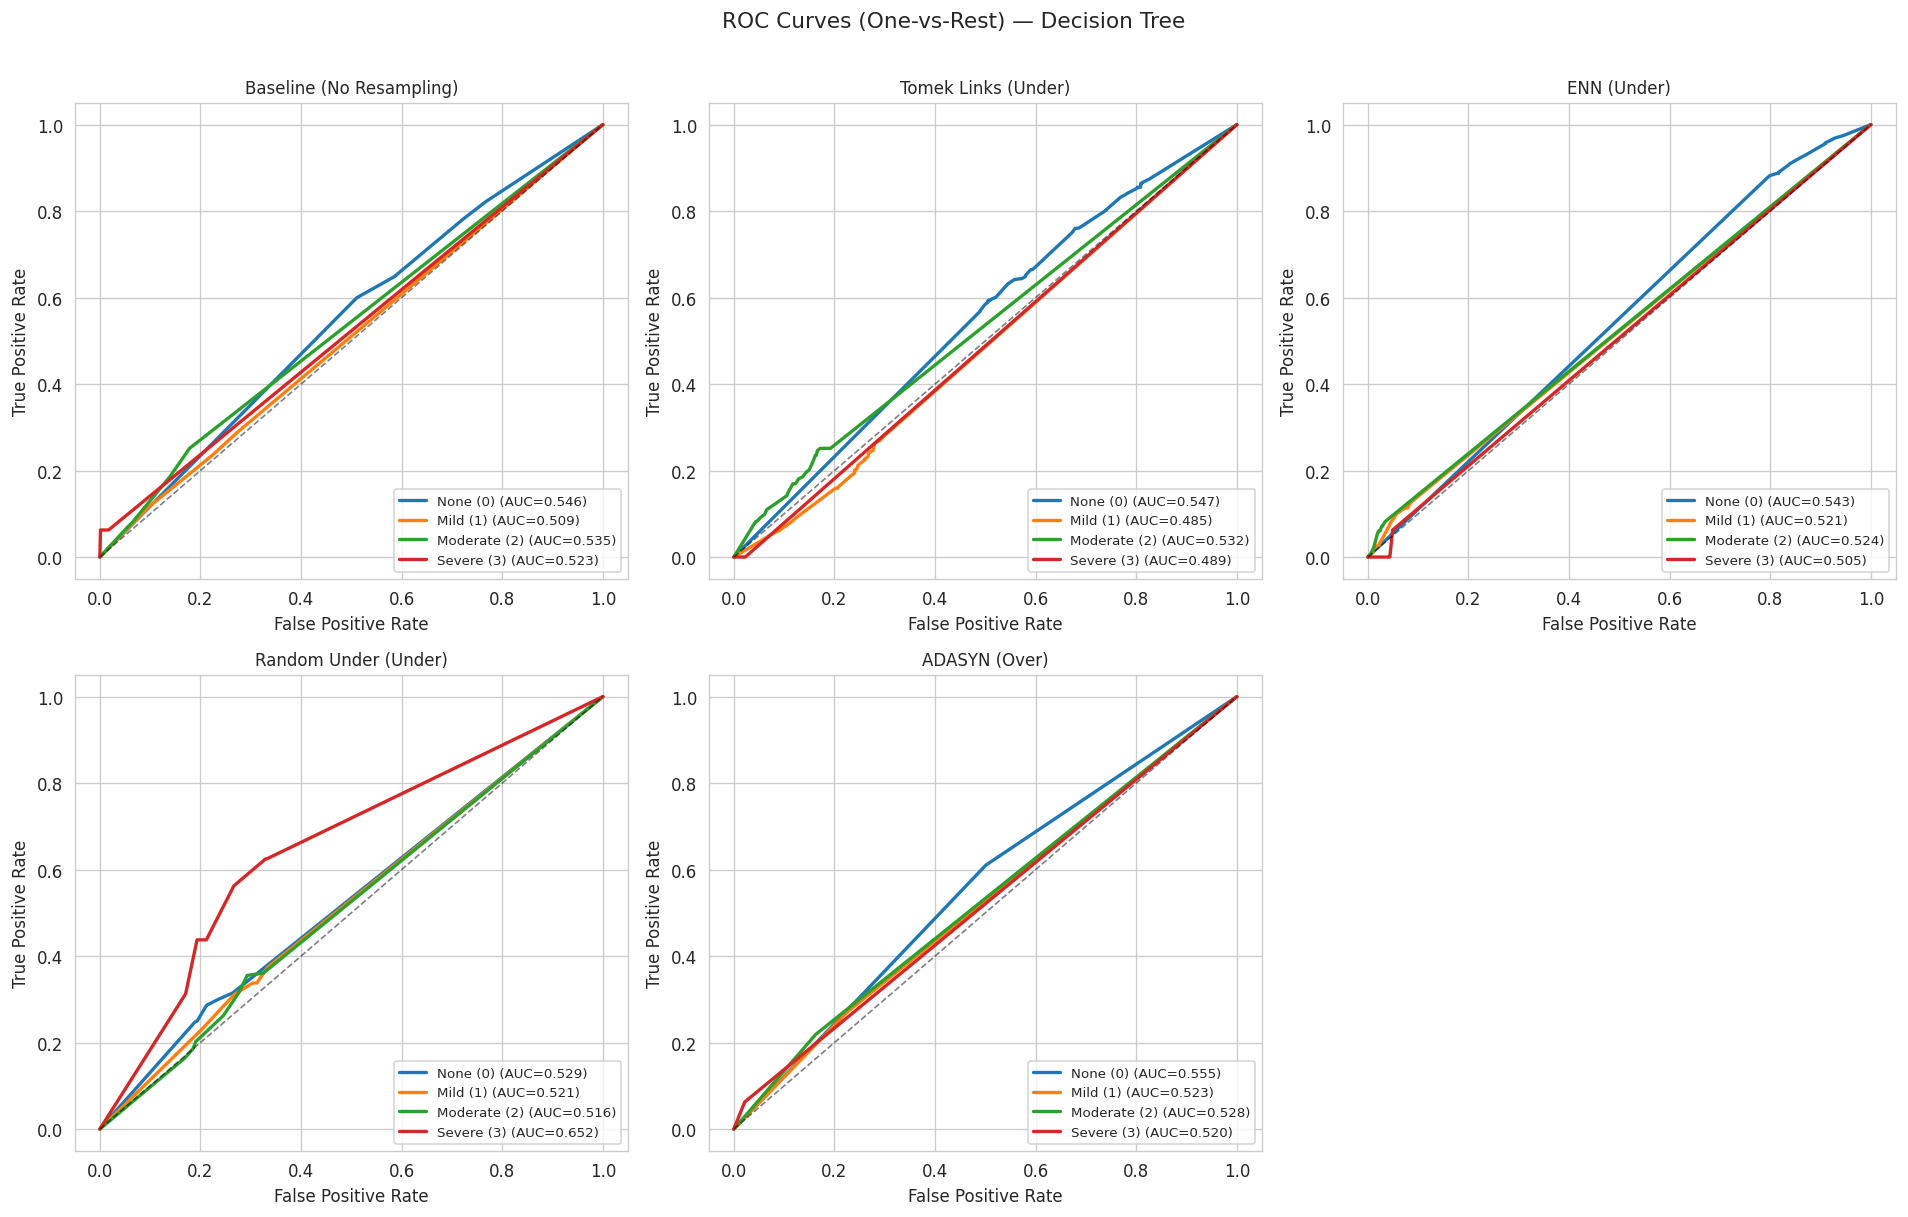

In [12]:
classes = sorted(y.unique())
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for ax, (key, res) in zip(axes.flat, results.items()):
    model = res["model"]
    y_score = model.predict_proba(X_test_scaled)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(key, fontsize=10)
    ax.legend(loc="lower right", fontsize=8)

# Hide unused subplot
axes[1, 2].set_visible(False)

plt.suptitle("ROC Curves (One-vs-Rest) — Decision Tree", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Summary Comparison

In [13]:
summary = pd.DataFrame({
    key: {
        "Best CV F1 (macro)": res["best_cv_score"],
        "Accuracy": res["accuracy"],
        "Precision (macro)": res["precision_macro"],
        "Recall (macro)": res["recall_macro"],
        "F1 (macro)": res["f1_macro"],
        "F1 (weighted)": res["f1_weighted"],
    }
    for key, res in results.items()
}).T

summary.index.name = "Resampling Strategy"
summary.round(4)

,Best CV F1 (macro),Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Resampling Strategy,,,,,,
Baseline (No Resampling),0.2963,0.5899,0.3456,0.2767,0.2852,0.5633
Tomek Links (Under),0.3084,0.4747,0.2596,0.2588,0.2547,0.5051
ENN (Under),0.3366,0.6746,0.3157,0.2615,0.2411,0.5833
Random Under (Under),0.3973,0.2937,0.2768,0.3283,0.2202,0.3541
ADASYN (Over),0.7469,0.4973,0.2802,0.2902,0.2796,0.5247


In [14]:
# Best hyperparameters per resampling strategy
params_df = pd.DataFrame({key: res["best_params"] for key, res in results.items()}).T
params_df.index.name = "Resampling Strategy"
params_df

,ccp_alpha,class_weight,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,splitter
Resampling Strategy,,,,,,,,
Baseline (No Resampling),0.0,None,gini,None,None,2,2,random
Tomek Links (Under),0.0,balanced,gini,20,None,2,2,random
ENN (Under),0.0,None,entropy,15,None,2,5,random
Random Under (Under),0.0,balanced,entropy,10,sqrt,1,2,best
ADASYN (Over),0.0,None,gini,None,None,1,2,random


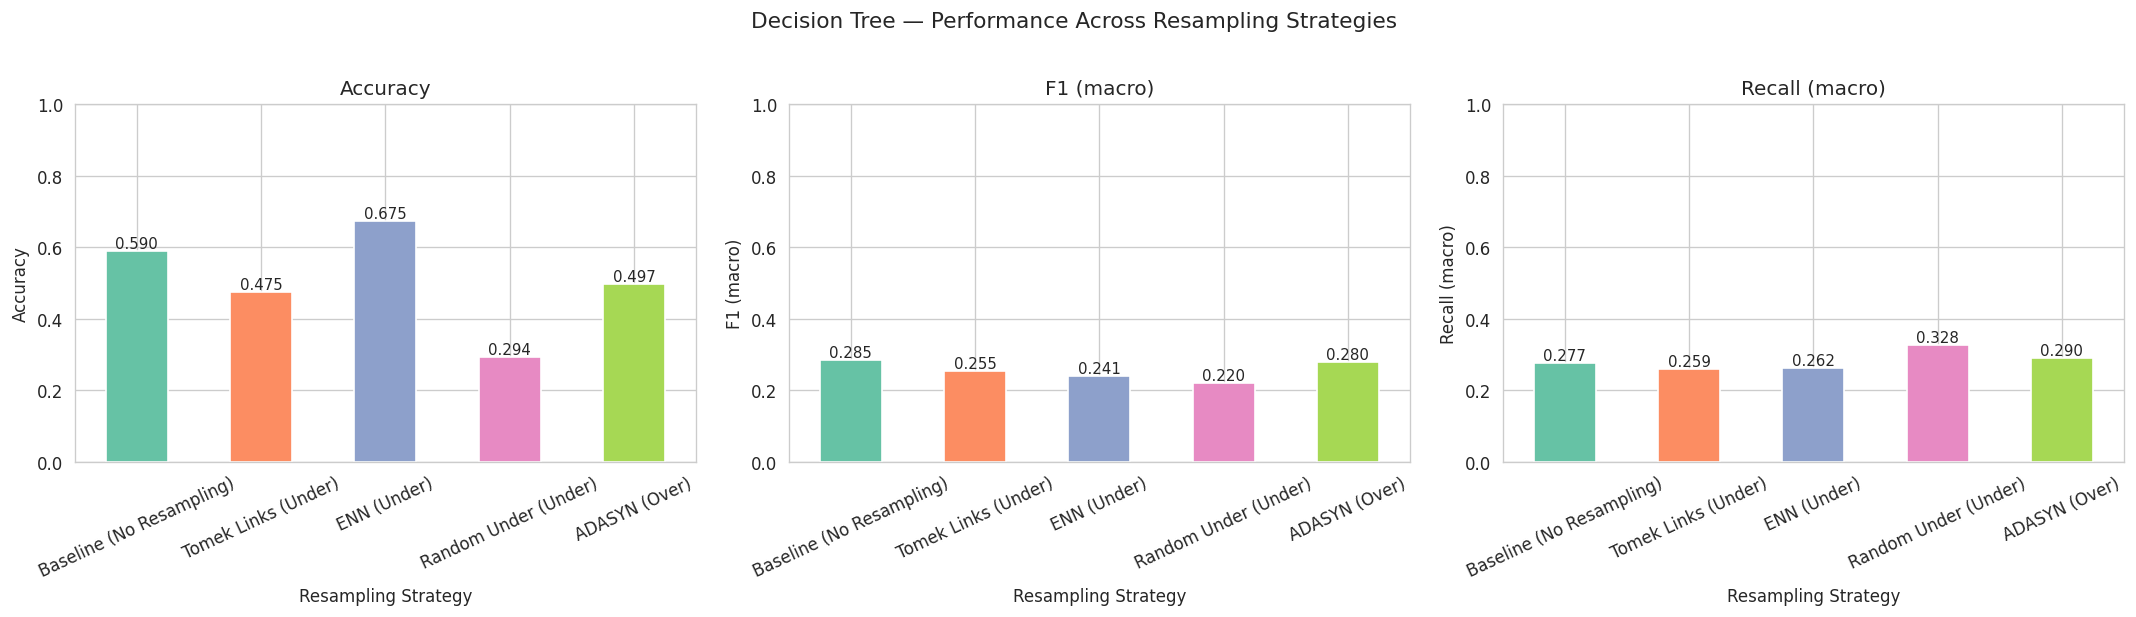

In [15]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ["Accuracy", "F1 (macro)", "Recall (macro)"]

for ax, metric in zip(axes, metrics_to_plot):
    summary[metric].plot(kind="bar", ax=ax, color=sns.color_palette("Set2", 5), rot=25)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                   ha="center", va="bottom", fontsize=9)

plt.suptitle("Decision Tree — Performance Across Resampling Strategies", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()